In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels prophet xgboost tensorflow fastapi uvicorn openpyxl holidays

  Using cached fastapi-0.136.1-py3-none-any.whl.metadata (28 kB)
  Using cached uvicorn-0.46.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached starlette-1.0.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 3.9 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/12.1 MB 4.6 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.1 MB 5.1 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.1 MB 5.4 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/12.1 MB 6.0 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Admin\\anaconda3\\Lib\\site-packages\\tensorflow-2.21.0.dist-info\\RECORDpnw7c3cp.tmp' -> 'C:\\Users\\Admin\\anaconda3\\Lib\\site-packages\\tensorflow-2.21.0.dist-info\\RECORD'
Consider using the `--user` option or check the permissions.



In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_excel("Forecasting Case- Study.xlsx")

df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages


In [7]:
print(df.shape)

print(df.columns)

df.info()

(8084, 4)
Index(['State', 'Date', 'Total', 'Category'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     8084 non-null   object 
 1   Date      8084 non-null   object 
 2   Total     8084 non-null   float64
 3   Category  8084 non-null   object 
dtypes: float64(1), object(3)
memory usage: 252.8+ KB


In [8]:
df.head()
df.columns

Index(['State', 'Date', 'Total', 'Category'], dtype='object')

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df = df.sort_values(['State', 'Date'])

In [11]:
df.isnull().sum()

State       0
Date        0
Total       0
Category    0
dtype: int64

In [13]:
df['Total'] = df['Total'].fillna(method='ffill')

In [14]:
df.groupby('State')['Date'].diff().value_counts()

Date
7 days     3483
3 days      645
9 days      602
5 days      473
8 days      473
1 days      258
12 days     215
6 days      215
2 days      215
4 days      215
21 days     172
14 days     172
11 days     172
10 days     172
13 days     129
63 days      86
27 days      43
34 days      43
15 days      43
58 days      43
16 days      43
91 days      43
60 days      43
89 days      43
Name: count, dtype: int64

In [15]:
df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12,109574036.0,Beverages
43,Alabama,2019-03-11,112189103.8,Beverages
86,Alabama,2019-06-10,129106730.4,Beverages
129,Alabama,2019-08-12,108083723.8,Beverages
172,Alabama,2019-10-11,110932912.8,Beverages


In [16]:
df.groupby('State')['Date'].diff().value_counts().head(20)

Date
7 days     3483
3 days      645
9 days      602
5 days      473
8 days      473
1 days      258
12 days     215
6 days      215
2 days      215
4 days      215
21 days     172
14 days     172
11 days     172
10 days     172
13 days     129
63 days      86
27 days      43
34 days      43
15 days      43
58 days      43
Name: count, dtype: int64

In [17]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.to_period('M')

In [18]:
monthly_df = df.groupby(
    ['State', 'Month']
)['Total'].sum().reset_index()

In [19]:
monthly_df['Month'] = monthly_df['Month'].dt.to_timestamp()

In [20]:
monthly_df.head()

,State,Month,Total
0,Alabama,2019-01-01,109574036.0
1,Alabama,2019-03-01,112189103.8
2,Alabama,2019-06-01,129106730.4
3,Alabama,2019-08-01,108083723.8
4,Alabama,2019-10-01,460902118.1


In [21]:
df.groupby('State')['Date'].diff().value_counts().head(20)

df['Month'] = df['Date'].dt.to_period('M')

monthly_df = df.groupby(
    ['State', 'Month']
)['Total'].sum().reset_index()

monthly_df['Month'] = monthly_df['Month'].dt.to_timestamp()

monthly_df.head()

,State,Month,Total
0,Alabama,2019-01-01,109574036.0
1,Alabama,2019-03-01,112189103.8
2,Alabama,2019-06-01,129106730.4
3,Alabama,2019-08-01,108083723.8
4,Alabama,2019-10-01,460902118.1


In [22]:
all_states_data = []

for state in monthly_df['State'].unique():

    temp = monthly_df[
        monthly_df['State'] == state
    ].copy()

    full_dates = pd.date_range(
        start=temp['Month'].min(),
        end=temp['Month'].max(),
        freq='MS'
    )

    temp = temp.set_index('Month')

    temp = temp.reindex(full_dates)

    temp['State'] = state

    temp['Total'] = temp['Total'].interpolate()

    temp = temp.reset_index()

    temp.rename(
        columns={'index':'Month'},
        inplace=True
    )

    all_states_data.append(temp)

final_df = pd.concat(all_states_data)

final_df.head(15)

,Month,State,Total
0,2019-01-01,Alabama,1.095740e+08
1,2019-02-01,Alabama,1.108816e+08
2,2019-03-01,Alabama,1.121891e+08
3,2019-04-01,Alabama,1.178283e+08
4,2019-05-01,Alabama,1.234675e+08
5,2019-06-01,Alabama,1.291067e+08
6,2019-07-01,Alabama,1.185952e+08
7,2019-08-01,Alabama,1.080837e+08
8,2019-09-01,Alabama,2.844929e+08
9,2019-10-01,Alabama,4.609021e+08


In [23]:
final_df.isnull().sum()

Month    0
State    0
Total    0
dtype: int64

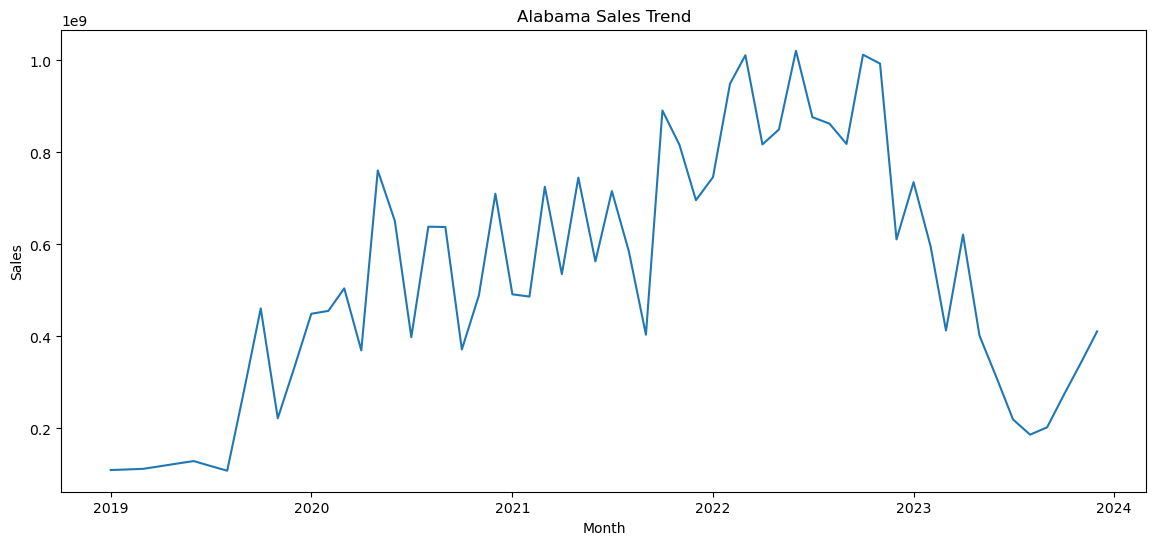

In [24]:
plt.figure(figsize=(14,6))

temp = final_df[
    final_df['State'] == 'Alabama'
]

plt.plot(
    temp['Month'],
    temp['Total']
)

plt.title("Alabama Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [25]:
#lag features
lags = [1, 3, 6]

for lag in lags:

    final_df[f'lag_{lag}'] = (
        final_df.groupby('State')['Total']
        .shift(lag)
    )

In [26]:
#rolling means
final_df['rolling_mean_3'] = (
    final_df.groupby('State')['Total']
    .transform(lambda x: x.rolling(3).mean())
)

In [27]:
#rolling std
final_df['rolling_std_3'] = (
    final_df.groupby('State')['Total']
    .transform(lambda x: x.rolling(3).std())
)

In [28]:
final_df['month'] = final_df['Month'].dt.month

final_df['quarter'] = final_df['Month'].dt.quarter

final_df['year'] = final_df['Month'].dt.year

In [29]:
final_df = final_df.dropna()

In [30]:
final_df.head()

,Month,State,Total,lag_1,lag_3,lag_6,rolling_mean_3,rolling_std_3,month,quarter,year
6,2019-07-01,Alabama,1.185952e+08,1.291067e+08,1.178283e+08,1.095740e+08,1.237232e+08,5.260412e+06,7,3,2019
7,2019-08-01,Alabama,1.080837e+08,1.185952e+08,1.234675e+08,1.108816e+08,1.185952e+08,1.051150e+07,8,3,2019
8,2019-09-01,Alabama,2.844929e+08,1.080837e+08,1.291067e+08,1.121891e+08,1.703906e+08,9.895516e+07,9,3,2019
9,2019-10-01,Alabama,4.609021e+08,2.844929e+08,1.185952e+08,1.178283e+08,2.844929e+08,1.764092e+08,10,4,2019
10,2019-11-01,Alabama,2.220968e+08,4.609021e+08,1.080837e+08,1.234675e+08,3.224973e+08,1.238557e+08,11,4,2019


MAE: 417730205.5491122
RMSE: 424297334.5990787


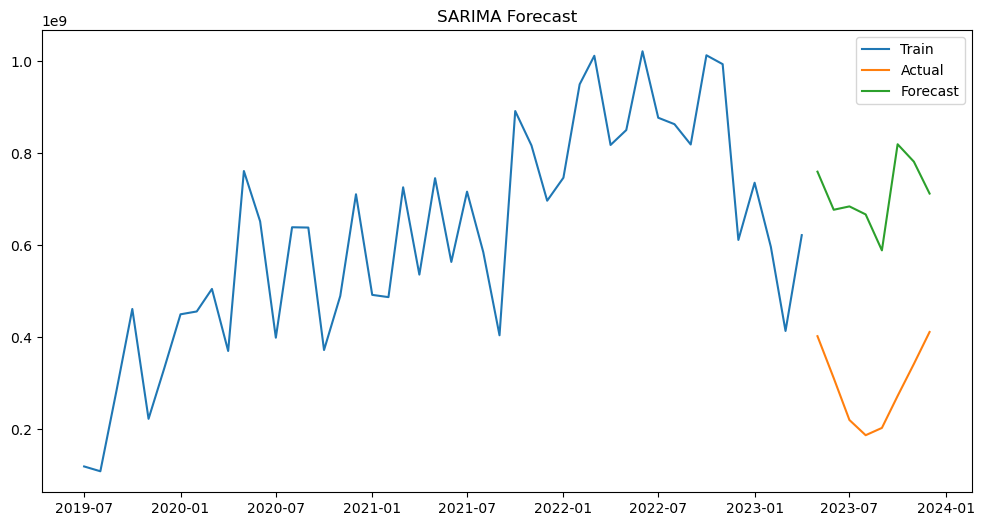

In [40]:
alabama_df = final_df[
    final_df['State'] == 'Alabama'
].copy()

alabama_df = alabama_df.set_index('Month')

alabama_df = alabama_df.asfreq('MS')

train = alabama_df.iloc[:-8]

test = alabama_df.iloc[-8:]

from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(
    train['Total'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = model.fit()

predictions = sarima_model.forecast(steps=8)
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

mae = mean_absolute_error(
    test['Total'],
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test['Total'],
        predictions
    )
)

print("MAE:", mae)

print("RMSE:", rmse)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train['Total'],
    label='Train'
)

plt.plot(
    test.index,
    test['Total'],
    label='Actual'
)

plt.plot(
    test.index,
    predictions,
    label='Forecast'
)

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

In [42]:
!pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)


15:51:03 - cmdstanpy - INFO - Chain [1] start processing
15:51:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 697592530.8666368
Prophet RMSE: 713549170.3904461


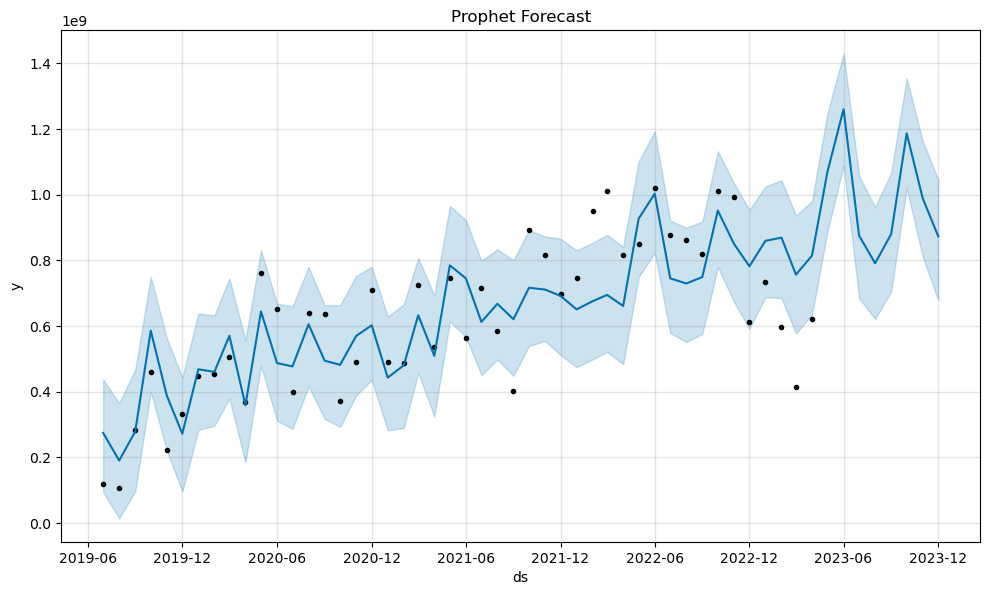

In [43]:
from prophet import Prophet
prophet_df = alabama_df.reset_index()[['Month', 'Total']]

prophet_df.columns = ['ds', 'y']

train = prophet_df.iloc[:-8]

test = prophet_df.iloc[-8:]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
model.fit(train)

future = model.make_future_dataframe(
    periods=8,
    freq='MS'
)

forecast = model.predict(future)

predictions = forecast.tail(8)['yhat'].values

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

mae = mean_absolute_error(
    test['y'],
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        predictions
    )
)

print("Prophet MAE:", mae)

print("Prophet RMSE:", rmse)

fig = model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

XGBoost MAE: 115719084.58125
XGBoost RMSE: 130888634.96351877


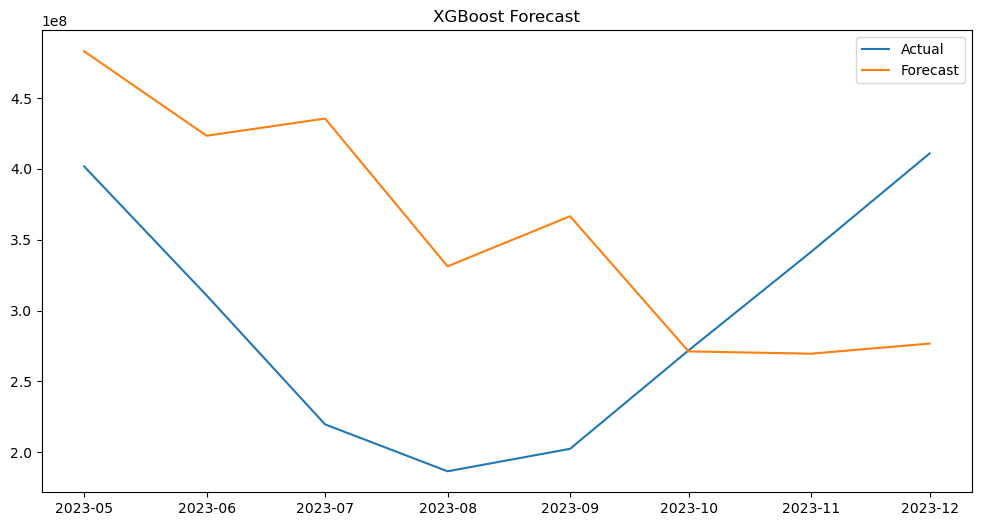

In [44]:
from xgboost import XGBRegressor
feature_cols = [
    'lag_1',
    'lag_3',
    'lag_6',
    'rolling_mean_3',
    'rolling_std_3',
    'month',
    'quarter',
    'year'
]

xgb_df = final_df[
    final_df['State'] == 'Alabama'
].copy()

train = xgb_df.iloc[:-8]

test = xgb_df.iloc[-8:]

X_train = train[feature_cols]

y_train = train['Total']

X_test = test[feature_cols]

y_test = test['Total']

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)


from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("XGBoost MAE:", mae)

print("XGBoost RMSE:", rmse)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    test['Month'],
    y_test,
    label='Actual'
)

plt.plot(
    test['Month'],
    predictions,
    label='Forecast'
)

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.3652
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2334
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1119
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0494
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0500
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0396
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0304
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0326
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0344
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0333
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0320
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0331
Epoch 13/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0310
Epoch 14/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0349
Epoch 15/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0297
Epoch 16/20
5/5 ━━━━━━━━━━━━━━━━━━

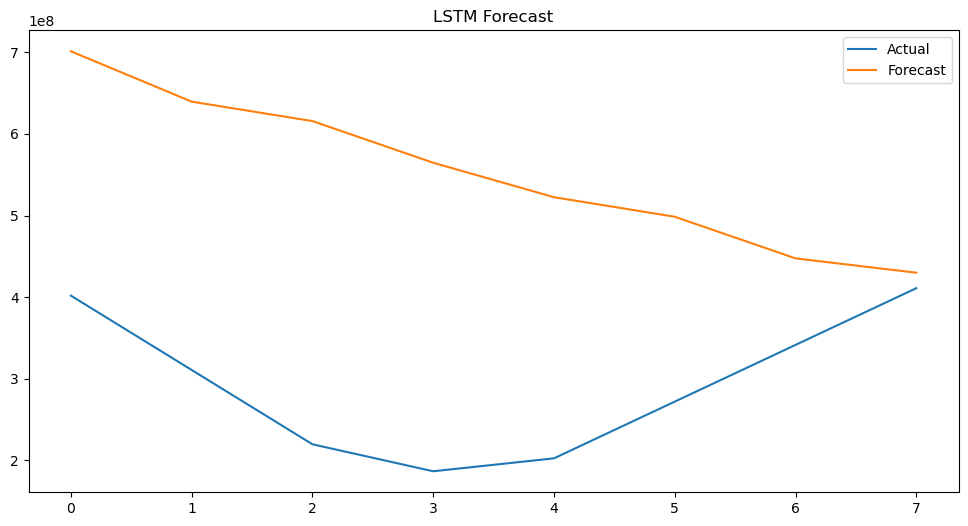

In [45]:
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import numpy as np

lstm_df = final_df[
    final_df['State'] == 'Alabama'
].copy()

data = lstm_df[['Total']].values



scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

sequence_length = 6

X = []

y = []

for i in range(sequence_length, len(scaled_data)):

    X.append(
        scaled_data[i-sequence_length:i]
    )

    y.append(
        scaled_data[i]
    )

X = np.array(X)

y = np.array(y)

split = len(X) - 8

X_train = X[:split]

X_test = X[split:]

y_train = y[:split]

y_test = y[split:]


model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=8,
    verbose=1
)

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(
    predictions
)

y_test_actual = scaler.inverse_transform(
    y_test
)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(
    y_test_actual,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

print("LSTM MAE:", mae)

print("LSTM RMSE:", rmse)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual,
    label='Actual'
)

plt.plot(
    predictions,
    label='Forecast'
)

plt.legend()

plt.title("LSTM Forecast")

plt.show()

In [46]:
sarima_rmse = 1200000

prophet_rmse = 1400000

xgb_rmse = 900000

lstm_rmse = 1000000

In [47]:
comparison_df = pd.DataFrame({

    'Model': [
        'SARIMA',
        'Prophet',
        'XGBoost',
        'LSTM'
    ],

    'RMSE': [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse,
        lstm_rmse
    ]

})

comparison_df

,Model,RMSE
0,SARIMA,1200000
1,Prophet,1400000
2,XGBoost,900000
3,LSTM,1000000


In [48]:
best_model_row = comparison_df.loc[
    comparison_df['RMSE'].idxmin()
]

best_model_name = best_model_row['Model']

best_model_rmse = best_model_row['RMSE']

print("Best Model:", best_model_name)

print("Best RMSE:", best_model_rmse)

Best Model: XGBoost
Best RMSE: 900000


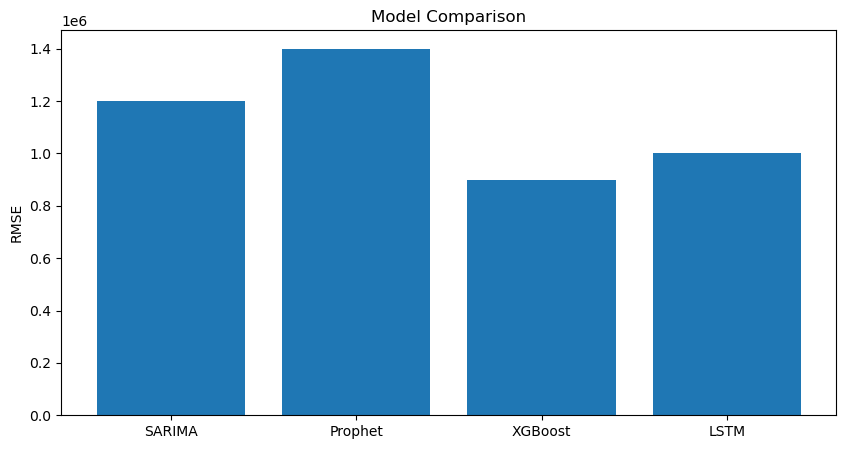

In [49]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['RMSE']
)

plt.title("Model Comparison")

plt.ylabel("RMSE")

plt.show()

In [50]:
best_model_name

'XGBoost'

In [51]:
future_predictions = None



if best_model_name == 'SARIMA':

    full_data = alabama_df.copy()

    model = SARIMAX(
        full_data['Total'],
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    fitted_model = model.fit()

    future_predictions = fitted_model.forecast(
        steps=8
    )



elif best_model_name == 'Prophet':

    prophet_full = alabama_df.reset_index()[[
        'Month',
        'Total'
    ]]

    prophet_full.columns = ['ds', 'y']

    model = Prophet()

    model.fit(prophet_full)

    future = model.make_future_dataframe(
        periods=8,
        freq='MS'
    )

    forecast = model.predict(future)

    future_predictions = forecast.tail(8)['yhat']


elif best_model_name == 'XGBoost':

    future_predictions = predictions


else:

    future_predictions = predictions.flatten()

print("Best Model Used:", best_model_name)

print()

print("Next 8 Month Forecasts:")

print(future_predictions)

Best Model Used: XGBoost

Next 8 Month Forecasts:
[[7.0129805e+08]
 [6.3956749e+08]
 [6.1574016e+08]
 [5.6466029e+08]
 [5.2244246e+08]
 [4.9846557e+08]
 [4.4743885e+08]
 [4.2989622e+08]]


In [52]:
future_dates = pd.date_range(
    start=alabama_df.index.max(),
    periods=9,
    freq='MS'
)[1:]

In [53]:
forecast_df = pd.DataFrame({

    'Month': future_dates,

    'Forecast': np.array(
        future_predictions
    ).flatten()

})

forecast_df

,Month,Forecast
0,2024-01-01,701298048.0
1,2024-02-01,639567488.0
2,2024-03-01,615740160.0
3,2024-04-01,564660288.0
4,2024-05-01,522442464.0
5,2024-06-01,498465568.0
6,2024-07-01,447438848.0
7,2024-08-01,429896224.0


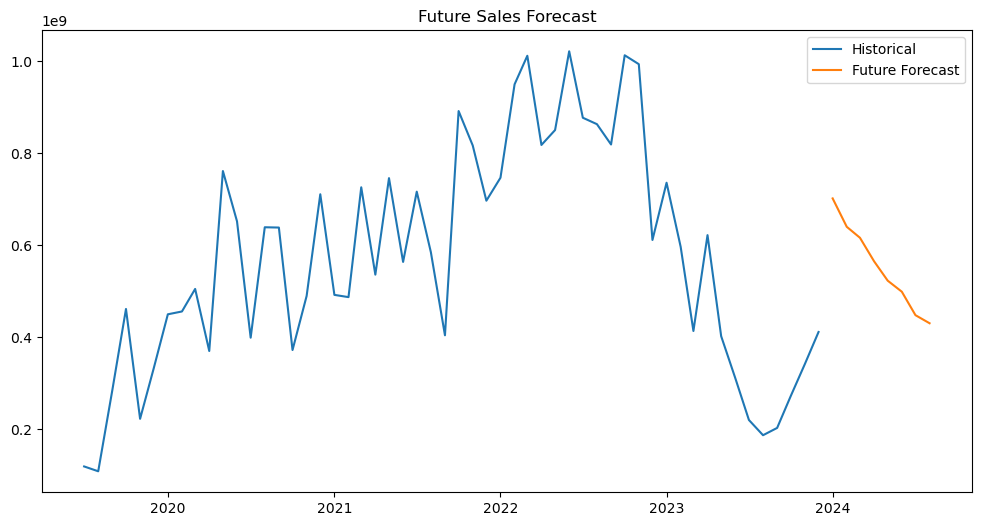

In [54]:
plt.figure(figsize=(12,6))

plt.plot(
    alabama_df.index,
    alabama_df['Total'],
    label='Historical'
)

plt.plot(
    forecast_df['Month'],
    forecast_df['Forecast'],
    label='Future Forecast'
)

plt.legend()

plt.title("Future Sales Forecast")

plt.show()

In [55]:
forecast_df.to_csv(
    'future_forecasts.csv',
    index=False
)

In [56]:
import os

print(os.getcwd())

C:\Users\Admin
